# Narrowband sqrt spherical harmonic
- basic notebook that samples IPTA MDC1 in linspharm basis using discovery -- new specspat formalism

In [2]:
import os
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'false'
import re
import inspect
import types
import typing
from collections.abc import Iterable
import functools
from pprint import pprint
import time

import numpy as np
import scipy.interpolate as si
import jax
from jax.scipy import stats as jss
import jax.numpy as jnp

from discovery import matrix
from discovery import const
import discovery as ds
import discovery.samplers.numpyro as ds_numpyro
import glob
import discovery.anis_coefficients as dac
import matplotlib.pyplot as plt
from discovery.glgp_specspat import makeglobalgp_fourier_specspat

/home/levis/miniforge3/envs/jhp_disco/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# sampling items
from numpyro import infer, distributions as dist
import numpyro
import scipy.stats as stats
import healpy as hp
from corner import corner
#import maps
import pandas as pd
import pyarrow.feather as feather
import enterprise.signals.anis_coefficients as ac
from PTMCMCSampler import PTMCMCSampler
import matplotlib.patches as mpatches

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
from defiant.extra import mdc1_utils
mdcpsrs, injparams = mdc1_utils.get_MDC1_psrs(use_pickle=True)

## model set up

In [7]:
psrs = mdcpsrs
T = ds.getspan(psrs)
comps = 2 # freq components
lmx = 2
nsi=1

ndict = {f'{p.name}_efac': 1.0 for p in psrs}
ndict.update({f'{p.name}_log10_t2equad': -7 for p in psrs})


psrpos = np.array([p.pos for p in psrs])

sqrtsphorfs = []
nblms = []
for c in range(comps):
    sqrtsph = dac.get_sqrtspharm_orf(psrpos, lmax=lmx)
    sqrtsphorfs.append(sqrtsph)
    nblms.append((lmx+1)**2-1)


glgp_mdc = makeglobalgp_fourier_specspat(psrs, [ds.freespectrum],
                                    [sqrtsphorfs],
                                    components=comps, T=T, name='gw', nbasis=[nblms])


m_mdc = ds.ArrayLikelihood([ds.PulsarLikelihood([psr.residuals,
                                             ds.makenoise_measurement_simple(psr, noisedict=ndict),
                                             ds.makegp_timing(psr, svd=True)]) for psr in psrs],
                       commongp = ds.makecommongp_fourier(psrs, ds.powerlaw, components=30, T=T, name='rednoise'),
                       globalgp = glgp_mdc)

# m_mdc = ds.GlobalLikelihood([ds.PulsarLikelihood([psr.residuals, #ds.makenoise_measurement_simple(psr, noisedict=ndict),
#                                              ds.makenoise_measurement_simple(psr),
#                                              ds.makegp_timing(psr, svd=True),
#                                              ds.makegp_fourier(psr, ds.powerlaw, components=30, name='rednoise')]) for psr in psrs],
#                                              globalgp = glgp_mdc)


mdc_jlogl = jax.jit(m_mdc.logL)

@jax.jit
def constrn_like(params):
    paramdict = {f'{p.name}_rednoise_gamma':1 for p in mdcpsrs}
    paramdict.update({f'{p.name}_rednoise_log10_A':-18 for p in mdcpsrs})
    aniparamct = 0 # LSS we do this in case we do not have the same number of clms for each freq component
    for c in range(comps):
        paramdict[f'gw_blm_f{c}({nblms[c]})'] = params[aniparamct:aniparamct+nblms[c]]
        aniparamct += nblms[c]

    paramdict[f'gw_log10_rho({comps})'] = params[-comps:]
    return m_mdc.logL(paramdict)


    

In [10]:
mdc_jlogl.params

['J0030+0451_rednoise_gamma',
 'J0030+0451_rednoise_log10_A',
 'J0218+4232_rednoise_gamma',
 'J0218+4232_rednoise_log10_A',
 'J0437-4715_rednoise_gamma',
 'J0437-4715_rednoise_log10_A',
 'J0613-0200_rednoise_gamma',
 'J0613-0200_rednoise_log10_A',
 'J0621+1002_rednoise_gamma',
 'J0621+1002_rednoise_log10_A',
 'J0711-6830_rednoise_gamma',
 'J0711-6830_rednoise_log10_A',
 'J0751+1807_rednoise_gamma',
 'J0751+1807_rednoise_log10_A',
 'J0900-3144_rednoise_gamma',
 'J0900-3144_rednoise_log10_A',
 'J1012+5307_rednoise_gamma',
 'J1012+5307_rednoise_log10_A',
 'J1022+1001_rednoise_gamma',
 'J1022+1001_rednoise_log10_A',
 'J1024-0719_rednoise_gamma',
 'J1024-0719_rednoise_log10_A',
 'J1045-4509_rednoise_gamma',
 'J1045-4509_rednoise_log10_A',
 'J1455-3330_rednoise_gamma',
 'J1455-3330_rednoise_log10_A',
 'J1600-3053_rednoise_gamma',
 'J1600-3053_rednoise_log10_A',
 'J1603-7202_rednoise_gamma',
 'J1603-7202_rednoise_log10_A',
 'J1640+2224_rednoise_gamma',
 'J1640+2224_rednoise_log10_A',
 'J1643-

In [16]:
numberofclms = sum(nblms)
tstpars = jnp.zeros(numberofclms + comps)
tstpars = tstpars.at[-comps:].set(np.ones(comps)*-6.0)
# tstpars = tstpars.at[-2].set(-7)
# tstpars = tstpars.at[-1].set(-6)

constrn_like(tstpars)

Array(40822.20776774, dtype=float64)

In [17]:
nparams = np.sum(nblms) + comps

In [18]:
# tstpars={}
# c1m0 = 10

# tstpars['gw_blm_f0(8)'] = np.zeros(nblms[0])
# tstpars['gw_blm_f0(8)'][0] = c1m0
# tstpars['gw_blm_f1(8)'] = np.zeros(nblms[1])
# tstpars['gw_log10_rho(2)'] = np.ones(comps)*-6.0

# pararr = np.zeros(nparams)
# pararr[0] = c1m0
# pararr[-2:] = np.ones(comps)*-6.0
# constrn_like(pararr)

In [19]:
constrn_like(tstpars)

Array(40822.20776774, dtype=float64)

In [20]:
%timeit constrn_like(tstpars).block_until_ready()

2.01 ms ± 59.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [52]:
rhopri = lambda x: jss.uniform.logpdf(x, -9, 5)
bl0pri = lambda x: jss.uniform.logpdf(x, 0, 50)
blm_amp_pri = lambda x: jss.uniform.logpdf(x, 0, 50)
blm_phase_pri = lambda x: jss.uniform.logpdf(x, 0, 2*jnp.pi)

m0ampidx = []
lmampidx = []
lmphsidx = []
for i in range(1, lmx+1):
    m0ampidx.append(i**2-1)
    lmpars = np.arange(i**2, (i+1)**2-1, dtype=int)
    lmampidx.extend(int(x) for x in lmpars[0::2])
    lmphsidx.extend(int(x) for x in lmpars[1::2])

m0ampidx = np.array(m0ampidx)
lmampidx = np.array(lmampidx)
lmphsidx = np.array(lmphsidx)



tstpars = np.zeros(nparams)
tstpars[-2:] = np.ones(comps)*-6.0


@jax.jit
def priorfunc(params):
    
    aniparamct = 0 # LSS we do this in case we do not have the same number of clms for each freq component
    full_blmprival = 0 # LSS a placeholder for the sum of the clm priors
    for c in range(comps):
        blms = params[aniparamct:aniparamct+nblms[c]]
        bl0prival = bl0pri(blms[m0ampidx])
        blmamp_prival = blm_amp_pri(blms[lmampidx])
        blmphs_prival = blm_phase_pri(blms[lmphsidx])
        blmprival = np.sum(bl0prival) + np.sum(blmamp_prival) + np.sum(blmphs_prival)
        full_blmprival += blmprival
        aniparamct += nblms[c]

    rhos = params[-comps:]
    rhoprival = jnp.sum(rhopri(rhos))
    fullpri = full_blmprival + rhoprival

    return fullpri

priorfunc(tstpars)

Array(-53.36636828, dtype=float64)

In [24]:
%timeit priorfunc(tstpars).block_until_ready()

22.2 μs ± 387 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [25]:
prigrad = jax.grad(priorfunc)
likgrad = jax.grad(constrn_like)

# prigradjump = lambda x: (priorfunc(x), prigrad(x))
# prigradlike = lambda x: (constrn_like(x), likgrad(x))

def prigradjump(x):
    return np.float64(priorfunc(x)).item(), np.array(prigrad(x))

def likegradjump(x):
    return np.float64(constrn_like(x)).item(), np.array(likgrad(x))

In [133]:
numberofblms = sum(nblms)

initcov = np.eye(nparams) * 0.01
# sampler = PTMCMCSampler.PTSampler(ndim=nparams, logl=constrn_like, logp=priorfunc,
#                                    logl_grad=likegradjump, logp_grad=prigradjump, cov=initcov,
#                                    outDir=f'./chains/narrow_lm{lmx}_{comps}f_gradjptst/', resume=False)


sampler = PTMCMCSampler.PTSampler(ndim=nparams, logl=constrn_like, logp=priorfunc, cov=initcov,
                                   outDir=f'./chains/sqrtspharm_narrow_lm{lmx}_{comps}f/', resume=False)

# def nothinglnlike(x):
#     return 1.0


#         bl0prival = bl0pri(blms[m0ampidx])
#         blmamp_prival = blm_amp_pri(blms[lmampidx])
#         blmphs_prival = blm_phase_pri(blms[lmphsidx])


# def draw_from_blm_prior(x, iter, beta):
#     '''Getting draws from blm prior'''
#     # key = jax.random.PRNGKey(iter)
#     q = x.copy()
#     # q = jnp.array(x)
    
#     lqxy = 0

#     aniparamct = 0 # LSS we do this in case we do not have the same number of clms for each freq component
#     full_blmprival = 0 # LSS a placeholder for the sum of the clm priors
#     for c in range(comps):
#             q[m0ampidx] = np.random.uniform(low=0, high=50, size=len(m0ampidx))
#         q[lmampidx] = np.random.uniform(low=0, high=50, size=len(lmampidx))
#         q[lmphsidx] = np.random.uniform(low=0, high=2*np.pi, size=len(lmphsidx))

#         blms = params[aniparamct:aniparamct+nblms[c]]
#         bl0prival = bl0pri(blms[m0ampidx])
#         blmamp_prival = blm_amp_pri(blms[lmampidx])
#         blmphs_prival = blm_phase_pri(blms[lmphsidx])
#         blmprival = np.sum(bl0prival) + np.sum(blmamp_prival) + np.sum(blmphs_prival)
#         full_blmprival += blmprival
#         aniparamct += nblms[c]


#     # LSS choose random clm - hardcoded what number params this corresponds to
#     #randclm = np.random.choice(numberofclms)
#     # q = q.at[randclm].set(jax.random.uniform(key, minval=-3, maxval=3))
#     q[m0ampidx] = np.random.uniform(low=0, high=50, size=len(m0ampidx))
#     q[lmampidx] = np.random.uniform(low=0, high=50, size=len(lmampidx))
#     q[lmphsidx] = np.random.uniform(low=0, high=2*np.pi, size=len(lmphsidx))


#     lqxy = clmpri(q) - clmpri(x)  # log proposal ratio for Metropolis-Hastings
#     #lqxy = lqxy.at[-comps:].set(rhopri(q[-comps:]) - rhopri(x[-comps:]))
#     lqxy = np.array(lqxy)
#     lqxy[-comps:] = np.zeros(comps)
#     return q, np.sum(lqxy)

# # def drawclmpri_wrap(x, iter, beta):
# #     return np.array(draw_from_clm_prior(x, iter, beta))

# # sampler.addProposalToCycle(draw_from_clm_prior, 50)

In [134]:
jax.devices()

[CudaDevice(id=0)]

In [135]:
tstpars = np.zeros(nparams)
tstpars[-2:] = np.ones(comps)*-6.0
tstpars[:-2] = 0.1
print(tstpars)

sampler.sample(Niter=100000, p0=np.array(tstpars),
               SCAMweight=0, AMweight=25, DEweight=50)

[ 0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1  0.1
  0.1  0.1 -6.  -6. ]
Finished 10.00 percent in 11.007786 s Acceptance rate = 0.2932Adding DE jump with weight 50
Finished 100.00 percent in 103.106062 s Acceptance rate = 0.32179
Run Complete


## Looking at the chain

In [8]:
chn = np.loadtxt(f'/home/levis/ipta_aniso_datachallenge/examples/chains/sqrtspharm_narrow_lm{lmx}_{comps}f/chain_1.txt')
# chn = np.loadtxt(f'/home/levis/ipta_aniso_datachallenge/examples/chains/priordrawtst/chain_1.txt')

In [9]:
chn.shape

(10001, 22)

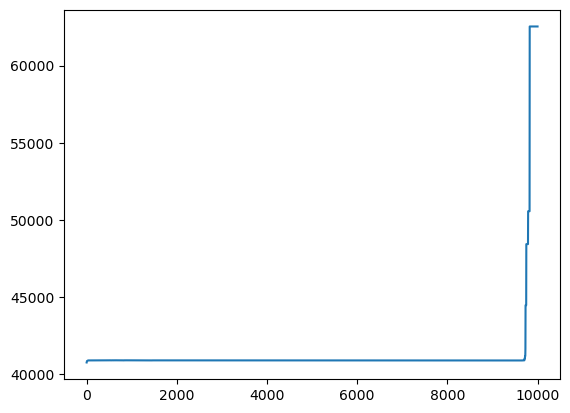

In [10]:
plt.plot(chn[:, -4])

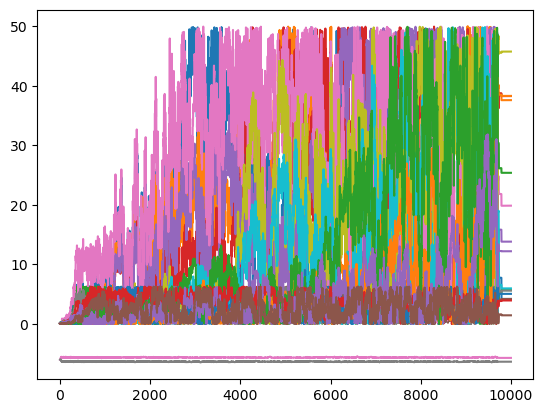

In [12]:
nparams = np.sum(nblms) + comps

for i in range(nparams):
    plt.plot(chn[:, i])  

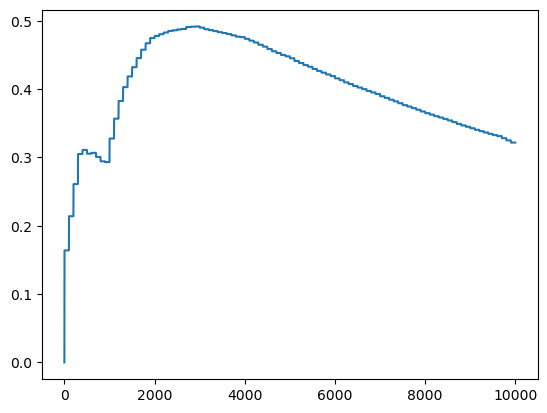

In [15]:
plt.plot(chn[:, -2])

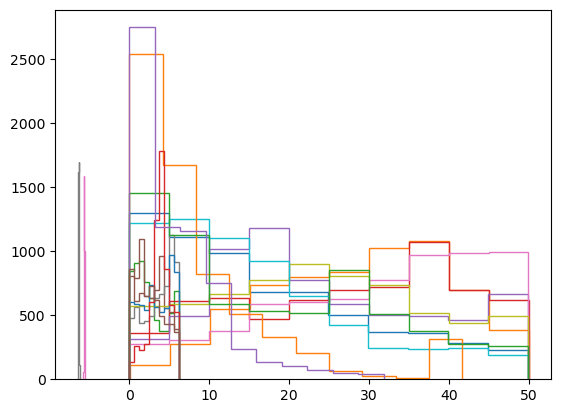

In [16]:
for i in range(nparams):
    plt.hist(chn[3500:, i], histtype='step')

plt.show()

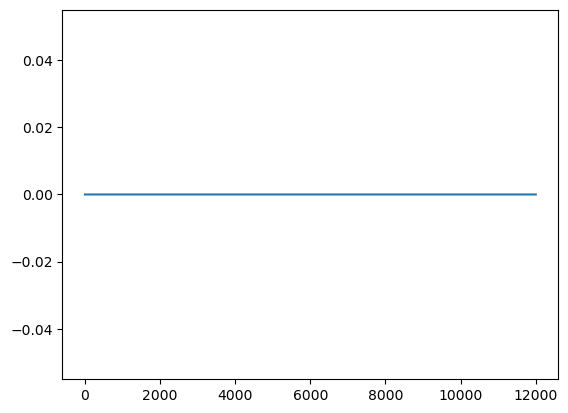

In [44]:
plt.plot(chn[8000:, 0])

In [122]:
lmx

2

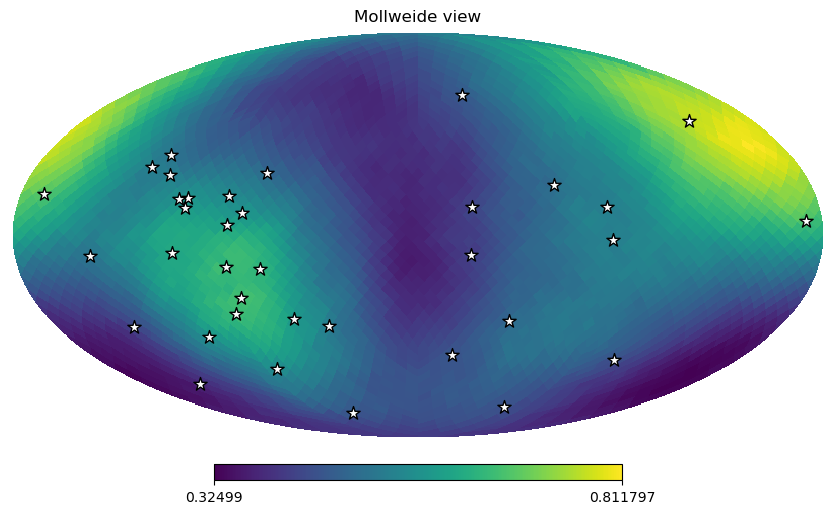

In [114]:
nsi = 16
smaps = []
for i in np.random.randint(2000, chn.shape[0], 1000):
    smaps.append(dac.clm2map(chn[i, :numberofclms], nside=nsi))
hp.mollview(np.median(smaps, axis=0), rot=180)
dac.plot_pulsars(psrs)


In [120]:
numberofclms

16

In [121]:
chn.shape

(20001, 22)

In [126]:
nclms

[8, 8]

In [127]:
print(lmx)
holdangpowf1 = np.zeros((1000, lmx))
holdangpowf2 = np.zeros((1000, lmx))
for i_idx, i in enumerate(np.random.randint(2000, chn.shape[0], 1000)):
    holdangpowf1[i_idx, :] = dac.clm2angpowspec(chn[i, :nclms[0]], lmax=lmx)
    holdangpowf2[i_idx, :] = dac.clm2angpowspec(chn[i, nclms[0]:nclms[1]+nclms[0]], lmax=lmx)

2


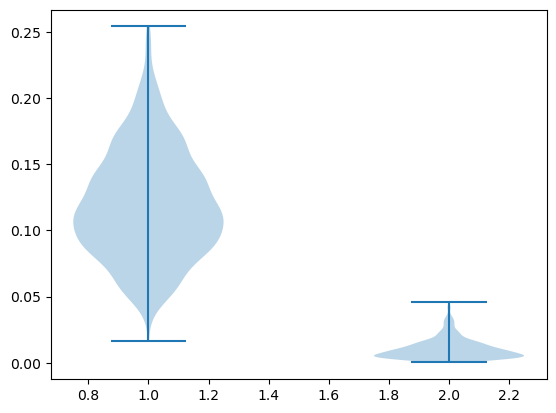

In [128]:
plt.violinplot(holdangpowf1/(4*np.pi), positions=np.arange(1, lmx+1));

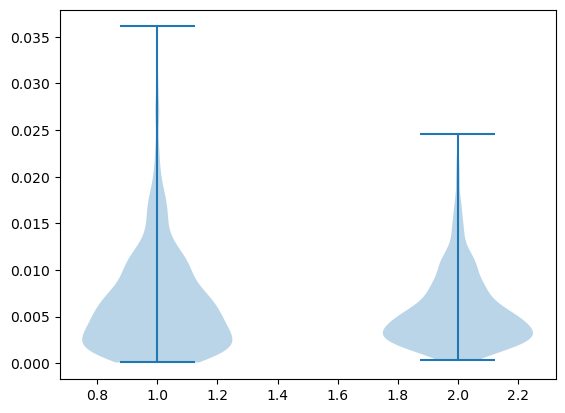

In [130]:
plt.violinplot(holdangpowf2/(4*np.pi), positions=np.arange(1, lmx+1));

(array([1363.,    0.,    0.,    0.,    0.,    0.,  139.,    0.,    0.,
        4399.]),
 array([1.10212521e+15, 1.19414769e+16, 2.27808286e+16, 3.36201804e+16,
        4.44595321e+16, 5.52988838e+16, 6.61382355e+16, 7.69775873e+16,
        8.78169390e+16, 9.86562907e+16, 1.09495642e+17]),
 <BarContainer object of 10 artists>)

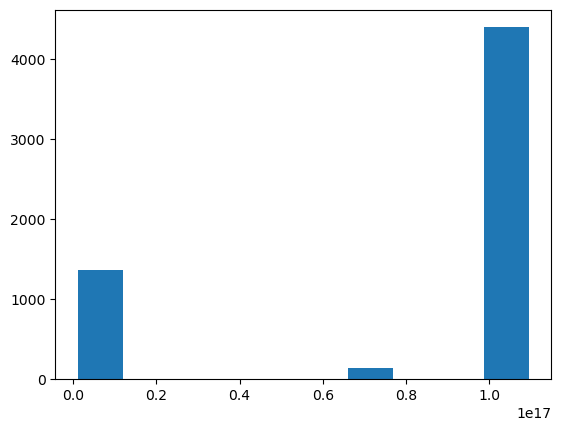

In [209]:
plt.hist(chn[10000:, -4])